In [1]:
from deconvolawrence.meta_processing import *
from deconvolawrence import ms_plotter_tools as msp

In [2]:
import sys
import os

# Automated deconvolution and quantification of mass spectra 
*Author - Lawrence Collins*

It is recommended to restart your computer before devconvolving large dataets (40+) as it is quite RAM intensive.
## Step 1: Load input file

Make sure to use double backslash. 
e.g. ``` path = "D:\\my mass spec folder\\my mass spec experiment\\mass_spec_input_file.xlsx" ```

### Setting up the input file

Sheet 1 of input file contains the directory folder of your mass spectra and the unidec configuration parameters. 

You can also add masses to detect and a corresponding colour. These are done by stipulating **Species** + *name* and **Color** + *name* in the Parameter column, followed by the desired mass or colour in the Input column.

A list of accepted colour names can be found [here](https://matplotlib.org/stable/gallery/color/named_colors.html)


**Example input directory**

| Parameter | Input | Comments |
| --- | --- |--- |
|Directory|D:\mass spec\protein labelling|
|Species Protein| 48127|
|Color Protein| orange|
|Start Scan|	490	|
|End Scan|540	|
|Tolerance (Da)	|10	|Peak matching tolerance |
|Config masslb	|15000|	Deconvolution window low mass|
|Config massub	|50000|	Deconvolution window high mass|
|Config massbins|	1|Mass bins for deconvolution - sample mass every|
|Config peakwindow|	10|	|
|Config peakthresh|0.05|	|
|Config minmz|	700|	m/z lower bounds (defaults to 0)|
|Config maxmz|		|m/z upper bounds (defaults to 10e12)|
|Config startz|	1	| |
|Config endz|	100	| |
|Config numz|	100	| |
|Config numit|	60	|number of iterations of deconvolution algorithm|

### Defining variables of different spectra

Each file within the directory can be linked to custom variables defined in a second sheet of the input directory. This comes in handy if wanting to filter data or perform analyses/comparison on subsets of your experiment. 

Any column names can be defined aside from 'Name' in column 0. Name corresponds to your filename (can be partial match).

Make sure var_ids=True ```load_input_file(var_ids = True)```  

**Example variables table**

|Name|	Peptide	|Catalyst|Time|
| --- | --- | --- | --- |
|240126 DoE Nexp 1	|1	|1	|1|
|240126 DoE Nexp 2	|2	|13	|3|
|240126 DoE Nexp 3	|1	|25	|3|
|240126 DoE Nexp 4	|3	|25	|1|
|240126 DoE Nexp 5	|2	|13	|5|
|240126 DoE Nexp 6	|3	|1	|3|
|240126 DoE Nexp 7	|3	|13	|1|
|240126 DoE Nexp 8	|2	|1	|5|
|240126 DoE Nexp 9	|1	|25	|5|




In [3]:
# path = "Meta2_input_file_v3.xlsx" # path to input file

# path = "Alexandra_MS_input_file.xlsx" # path to input file

path = "240612 DoE input file - MBP.xlsx"

eng = Meta2() # load engine

eng.load_input_file(path, unzip=False, clearhdf5=True, var_ids=True) # load input file and run deconvolution

eng.on_unidec() # run deconvolution


UniDec Engine v.6.0.4

UniDec Path: C:\Users\cm19ljc\Anaconda3\envs\deconvolawrence\lib\site-packages\unidec\bin\unidec.exe
Specified BAF has 741 spectra with line and profile data.
Specified BAF has 741 spectra with line and profile data.
Specified BAF has 741 spectra with line and profile data.
Specified BAF has 738 spectra with line and profile data.
Specified BAF has 741 spectra with line and profile data.
Specified BAF has 741 spectra with line and profile data.
Specified BAF has 740 spectra with line and profile data.
Specified BAF has 740 spectra with line and profile data.
Specified BAF has 740 spectra with line and profile data.
Specified BAF has 740 spectra with line and profile data.
Specified BAF has 739 spectra with line and profile data.
Specified BAF has 738 spectra with line and profile data.
Specified BAF has 742 spectra with line and profile data.
Specified BAF has 741 spectra with line and profile data.
Specified BAF has 741 spectra with line and profile data.
Speci

In [4]:
pd.read_excel(path, 0)

,Parameter,Input,Comments
0,Directory,D:\240612 DoE Mass Spectra\Files,NaN
1,Start Scan,427,NaN
2,End Scan,542,NaN
3,Species MBP-LPETGA,42333,NaN
4,Species MBP-LPETGVSEYG,41888,NaN
5,Species MBP-LPET,41295,NaN
6,Tolerance (Da),10,Peak matching tolerance
7,Config masslb,40000,Deconvolution window low mass
8,Config massub,45000,Deconvolution window high mass
9,Config massbins,1,Mass bins for deconvolution - sample mass every


In [5]:
eng.results1

,Name,Reaction name,Exp Name,Run Order,Incl/Excl,Catalyst,Temperature,Time,Abs conc,Label,Mass,Height,Color,Percentage_Labelling
0,240612 DoE N1 v2_2-1-43_1_13667,1,N1,14,Incl,1.0,4.0,1.0,20,MBP-LPETGVSEYG,41892.0,366.473175,green,4.841984
1,240612 DoE N1 v2_2-1-43_1_13667,1,N1,14,Incl,1.0,4.0,1.0,20,MBP-LPETGA,42336.0,7202.183594,blue,95.158020
2,240612 DoE N2 v2_2-1-44_1_13668,2,N2,1,Incl,10.0,4.0,1.0,20,MBP-LPETGVSEYG,41891.0,708.174500,green,12.045016
3,240612 DoE N2 v2_2-1-44_1_13668,2,N2,1,Incl,10.0,4.0,1.0,20,MBP-LPETGA,42336.0,5171.224121,blue,87.954987
4,240612 DoE N3_2-2-4_1_13643,3,N3,7,Incl,1.0,25.0,1.0,20,MBP-LPETGVSEYG,41893.0,357.762207,green,5.020966
5,240612 DoE N3_2-2-4_1_13643,3,N3,7,Incl,1.0,25.0,1.0,20,MBP-LPETGA,42336.0,6767.604004,blue,94.979034
6,240612 DoE N4_2-2-5_1_13644,4,N4,15,Incl,10.0,25.0,1.0,20,MBP-LPET,41297.0,257.500885,red,4.257463
7,240612 DoE N4_2-2-5_1_13644,4,N4,15,Incl,10.0,25.0,1.0,20,MBP-LPETGVSEYG,41891.0,1700.486572,green,28.115473
8,240612 DoE N4_2-2-5_1_13644,4,N4,15,Incl,10.0,25.0,1.0,20,MBP-LPETGA,42336.0,4090.235840,blue,67.627068
9,240614 DoE N5 v2_3-1-12_1_13838,5,N5,16,Incl,1.0,4.0,30.0,20,MBP-LPETGVSEYG,41895.0,1177.728027,green,20.478073


In [6]:
eng.results_df

,Name,Reaction name,Exp Name,Run Order,Incl/Excl,Catalyst,Temperature,Time,Abs conc,MBP-LPET,MBP-LPETGA,MBP-LPETGVSEYG,MBP-LPET,MBP-LPETGA,MBP-LPETGVSEYG
0,240612 DoE N1 v2_2-1-43_1_13667,1,N1,14,Incl,1.0,4.0,1.0,20,0.000000,7202.183594,366.473175,0.000000,95.158020,4.841984
1,240612 DoE N2 v2_2-1-44_1_13668,2,N2,1,Incl,10.0,4.0,1.0,20,0.000000,5171.224121,708.174500,0.000000,87.954987,12.045016
2,240612 DoE N3_2-2-4_1_13643,3,N3,7,Incl,1.0,25.0,1.0,20,0.000000,6767.604004,357.762207,0.000000,94.979034,5.020966
3,240612 DoE N4_2-2-5_1_13644,4,N4,15,Incl,10.0,25.0,1.0,20,257.500885,4090.235840,1700.486572,4.257463,67.627068,28.115473
4,240614 DoE N5 v2_3-1-12_1_13838,5,N5,16,Incl,1.0,4.0,30.0,20,0.000000,4573.438477,1177.728027,0.000000,79.521927,20.478073
5,240614 DoE N6 v2_3-1-13_1_13848,6,N6,18,Incl,10.0,4.0,30.0,20,1081.924683,594.467163,5007.011230,16.188231,8.894677,74.917091
6,240612 DoE N7_2-1-33_1_13674,7,N7,12,Incl,1.0,25.0,30.0,20,961.962585,3370.117676,4488.989258,10.905283,38.205318,50.889404
7,240612 DoE N8_2-1-34_1_13675,8,N8,19,Incl,10.0,25.0,30.0,20,2434.196777,0.000000,2124.180176,53.400517,0.000000,46.599483
8,240604 DoE N9_1-1-9_1_13478,9,N9,10,Incl,1.0,4.0,1.0,200,0.000000,4046.976562,355.333405,0.000000,91.928474,8.071522
9,240604 DoE N10_1-1-10_1_13479,10,N10,2,Incl,10.0,4.0,1.0,200,0.000000,2730.568115,1077.703613,0.000000,71.700981,28.299023


## Step 2: Plotting mass spectra

Mass spectra can be plotted separately and exported to *UniDec_Figures_and_Files* within your directory. 

### Useful commands

You can plot the deconvolved spectrum ```attr = "massdat"``` or the raw spectrum ```attr = "data2"``` (make sure to change the xlabel to m/z if plotting the raw spectrum ```xlabel = "m/z"```)

```window= [12000, 14000] ``` A mass window over which to plot over 

```legend = True``` to add a legend of the masses found within the spectra

```show_peaks = True``` to pick the peaks that correspond to defined species from the input file found in the spectrum

```fmt="svg"``` to plot in vector format (editable in photoshop) or ```fmt = 'png'``` for image files

### Combining spectra to a single figure 
Spectra can be stacked for nice made-for-publication figures. This can be combined with any defined variables within the second sheet of your input file to separate desired mass spectra to be stacked - e.g. if plotting a time course. 

To separate groups of spectra by variables from the second sheet of the input file into combined figures, define ```groupby = [variable_x]``` and ```combine = True``` (can be grouped by more than one variable by writing a list of variables into groupby).

In [24]:
spectra = eng.eng.data.spectra

# add in zoomed function that plots over window using min and max masses contained in masslist 
msp.plot_spectra_separate(spectra, attr = "massdat", xlabel = "Mass [Da]", 
                          export=True, c='black',lw=0.7,window = [41050, 42750],
                         show_peaks=True,legend=True, directory =eng.directory, fmt='png')

# msp.plot_spectra_separate(spectra, attr = "data2", xlabel = "m/z", export=False)


# eng.group_spectra("GVSEYG")

Fig exported to:  D:\240612 DoE Mass Spectra\Files\UniDec_Figures_and_Files\240612 DoE N8_2-1-34_1_13675.d_massdat_41050_42750_img.png
Fig exported to:  D:\240612 DoE Mass Spectra\Files\UniDec_Figures_and_Files\240612 DoE N11_2-2-6_1_13645.d_massdat_41050_42750_img.png
Fig exported to:  D:\240612 DoE Mass Spectra\Files\UniDec_Figures_and_Files\240612 DoE N12_2-2-7_1_13646.d_massdat_41050_42750_img.png
Fig exported to:  D:\240612 DoE Mass Spectra\Files\UniDec_Figures_and_Files\240612 DoE N13_1-1-1_1_13653.d_massdat_41050_42750_img.png
Fig exported to:  D:\240612 DoE Mass Spectra\Files\UniDec_Figures_and_Files\240612 DoE N14_1-1-2_1_13654.d_massdat_41050_42750_img.png
Fig exported to:  D:\240612 DoE Mass Spectra\Files\UniDec_Figures_and_Files\240612 DoE N15_2-1-31_1_13672.d_massdat_41050_42750_img.png
Fig exported to:  D:\240612 DoE Mass Spectra\Files\UniDec_Figures_and_Files\240612 DoE N16_2-1-32_1_13673.d_massdat_41050_42750_img.png
Fig exported to:  D:\240612 DoE Mass Spectra\Files\Un

In [8]:
# eng.plot_spectra(combine=True, groupby='GVSEYG',show_titles=False)

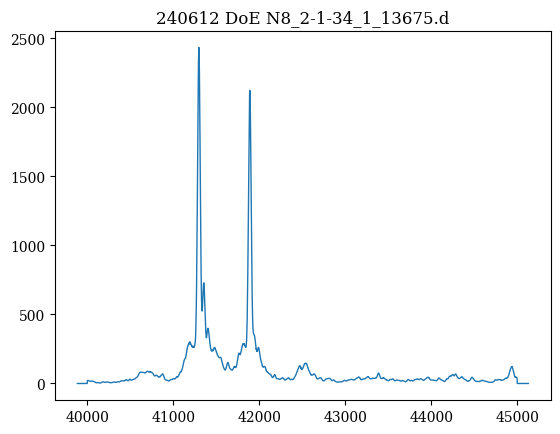

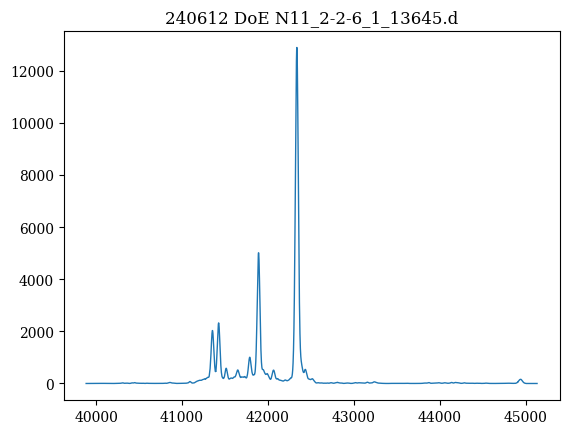

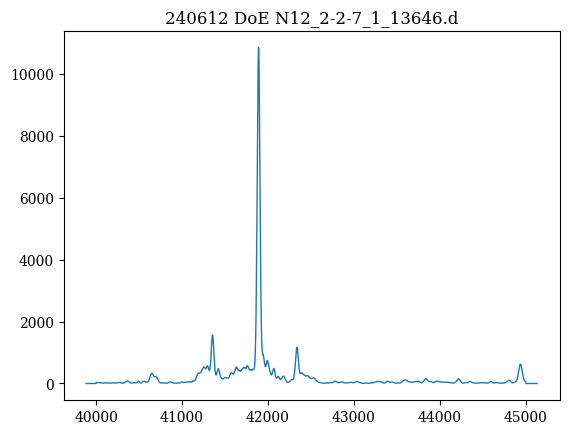

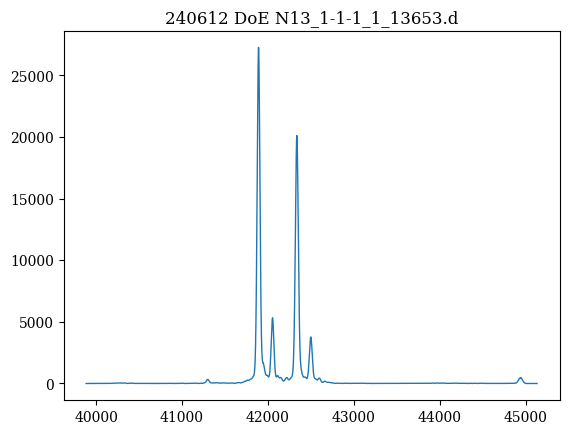

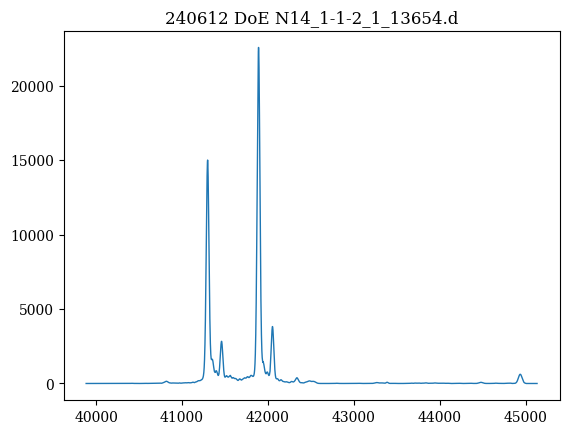

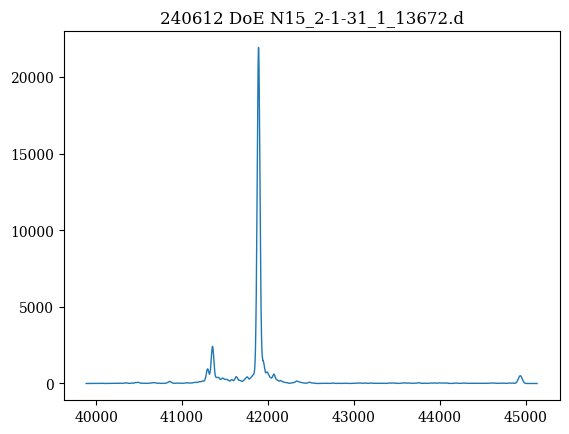

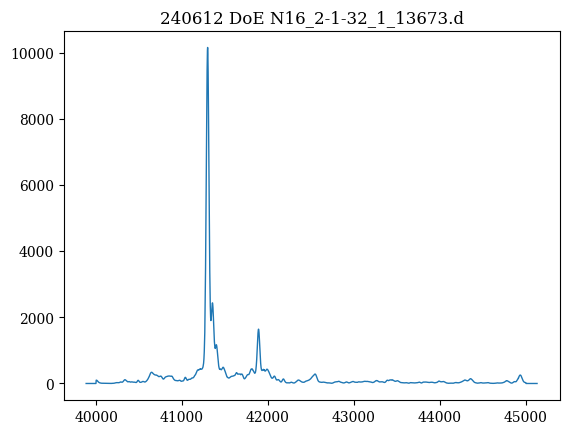

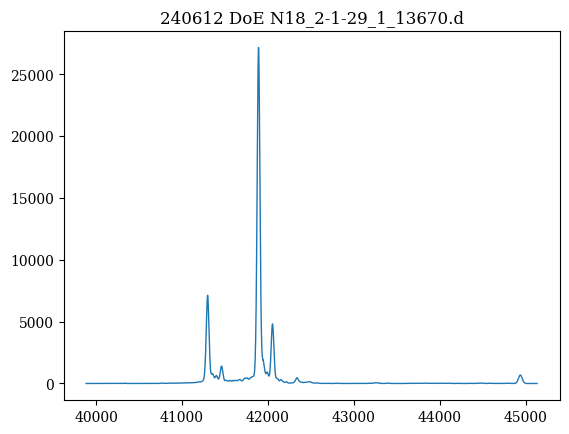

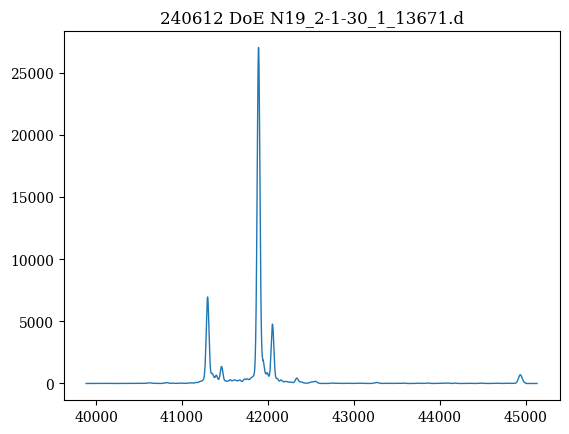

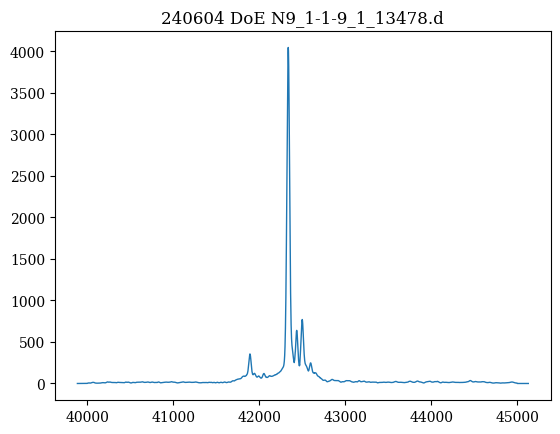

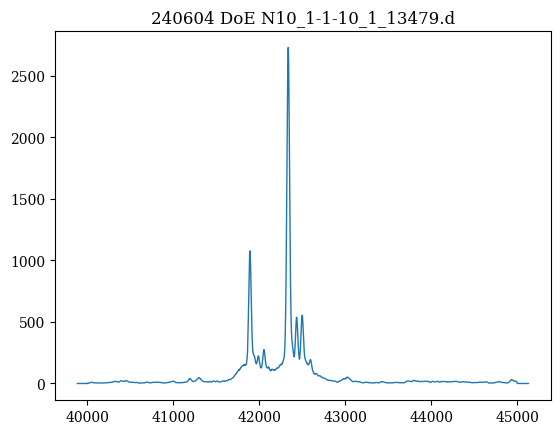

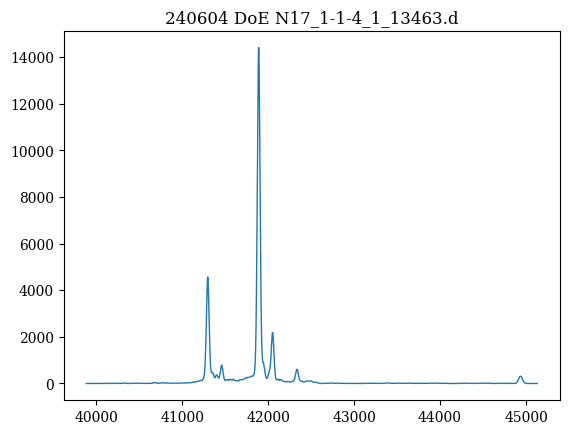

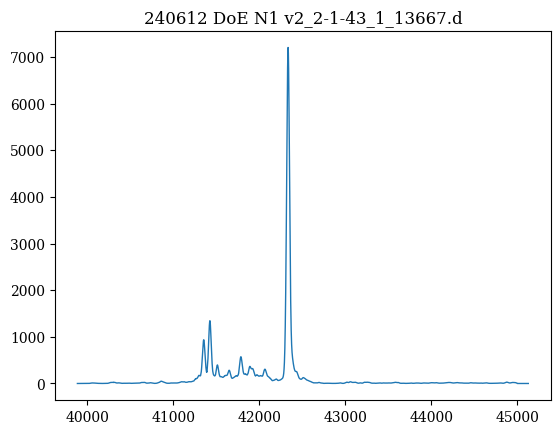

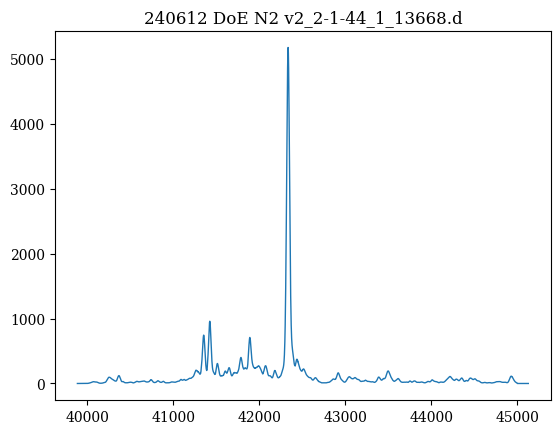

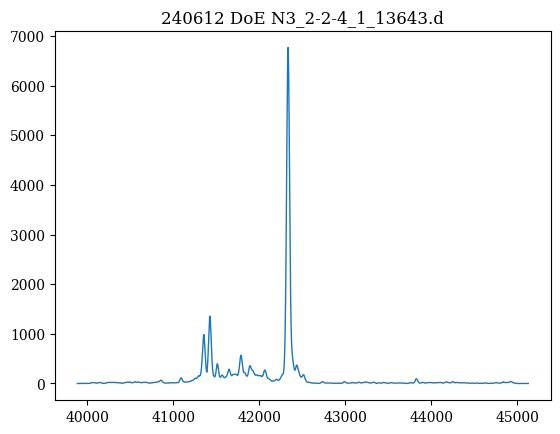

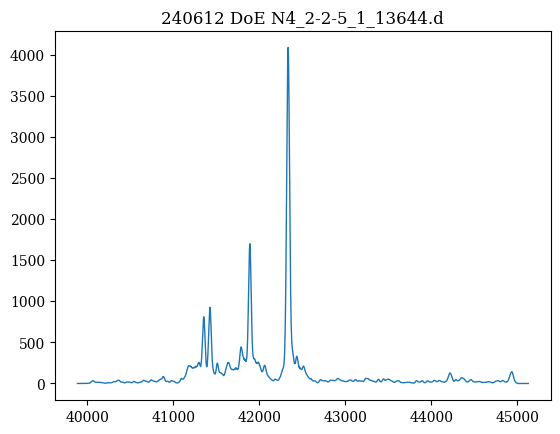

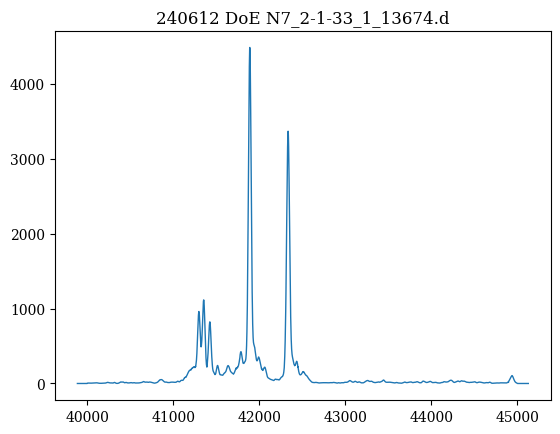

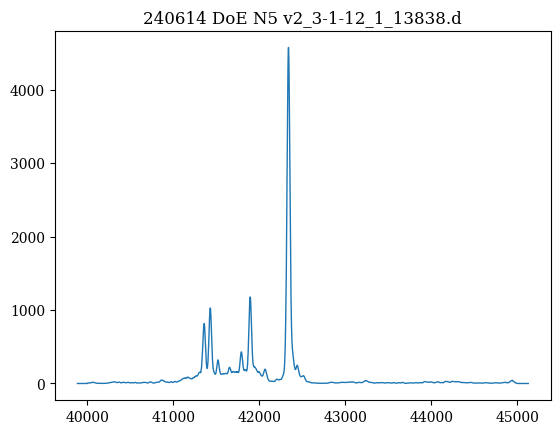

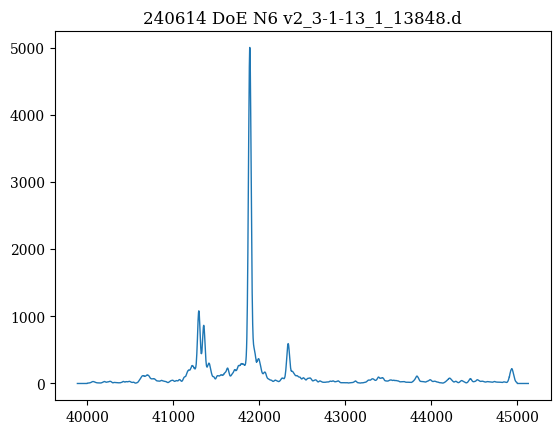

In [9]:
for s in spectra:
    plt.plot(s.massdat[:, 0], s.massdat[:, 1])
    plt.title(s.name)
    plt.show()

In [10]:
sorted_spectra = []
df = eng.results_df
spectra = eng.eng.data.spectra

df
for row in df.iterrows():
    name = row[1].Name
    print(name)
    for s in spectra:

        named = [s for s in spectra if s.name[:-2] == name][0]
    sorted_spectra.append(named)
# name

240612 DoE N1 v2_2-1-43_1_13667
240612 DoE N2 v2_2-1-44_1_13668
240612 DoE N3_2-2-4_1_13643
240612 DoE N4_2-2-5_1_13644
240614 DoE N5 v2_3-1-12_1_13838
240614 DoE N6 v2_3-1-13_1_13848
240612 DoE N7_2-1-33_1_13674
240612 DoE N8_2-1-34_1_13675
240604 DoE N9_1-1-9_1_13478
240604 DoE N10_1-1-10_1_13479
240612 DoE N11_2-2-6_1_13645
240612 DoE N12_2-2-7_1_13646
240612 DoE N13_1-1-1_1_13653
240612 DoE N14_1-1-2_1_13654
240612 DoE N15_2-1-31_1_13672
240612 DoE N16_2-1-32_1_13673
240604 DoE N17_1-1-4_1_13463
240612 DoE N18_2-1-29_1_13670
240612 DoE N19_2-1-30_1_13671


In [11]:
df

,Name,Reaction name,Exp Name,Run Order,Incl/Excl,Catalyst,Temperature,Time,Abs conc,MBP-LPET,MBP-LPETGA,MBP-LPETGVSEYG,MBP-LPET,MBP-LPETGA,MBP-LPETGVSEYG
0,240612 DoE N1 v2_2-1-43_1_13667,1,N1,14,Incl,1.0,4.0,1.0,20,0.000000,7202.183594,366.473175,0.000000,95.158020,4.841984
1,240612 DoE N2 v2_2-1-44_1_13668,2,N2,1,Incl,10.0,4.0,1.0,20,0.000000,5171.224121,708.174500,0.000000,87.954987,12.045016
2,240612 DoE N3_2-2-4_1_13643,3,N3,7,Incl,1.0,25.0,1.0,20,0.000000,6767.604004,357.762207,0.000000,94.979034,5.020966
3,240612 DoE N4_2-2-5_1_13644,4,N4,15,Incl,10.0,25.0,1.0,20,257.500885,4090.235840,1700.486572,4.257463,67.627068,28.115473
4,240614 DoE N5 v2_3-1-12_1_13838,5,N5,16,Incl,1.0,4.0,30.0,20,0.000000,4573.438477,1177.728027,0.000000,79.521927,20.478073
5,240614 DoE N6 v2_3-1-13_1_13848,6,N6,18,Incl,10.0,4.0,30.0,20,1081.924683,594.467163,5007.011230,16.188231,8.894677,74.917091
6,240612 DoE N7_2-1-33_1_13674,7,N7,12,Incl,1.0,25.0,30.0,20,961.962585,3370.117676,4488.989258,10.905283,38.205318,50.889404
7,240612 DoE N8_2-1-34_1_13675,8,N8,19,Incl,10.0,25.0,30.0,20,2434.196777,0.000000,2124.180176,53.400517,0.000000,46.599483
8,240604 DoE N9_1-1-9_1_13478,9,N9,10,Incl,1.0,4.0,1.0,200,0.000000,4046.976562,355.333405,0.000000,91.928474,8.071522
9,240604 DoE N10_1-1-10_1_13479,10,N10,2,Incl,10.0,4.0,1.0,200,0.000000,2730.568115,1077.703613,0.000000,71.700981,28.299023


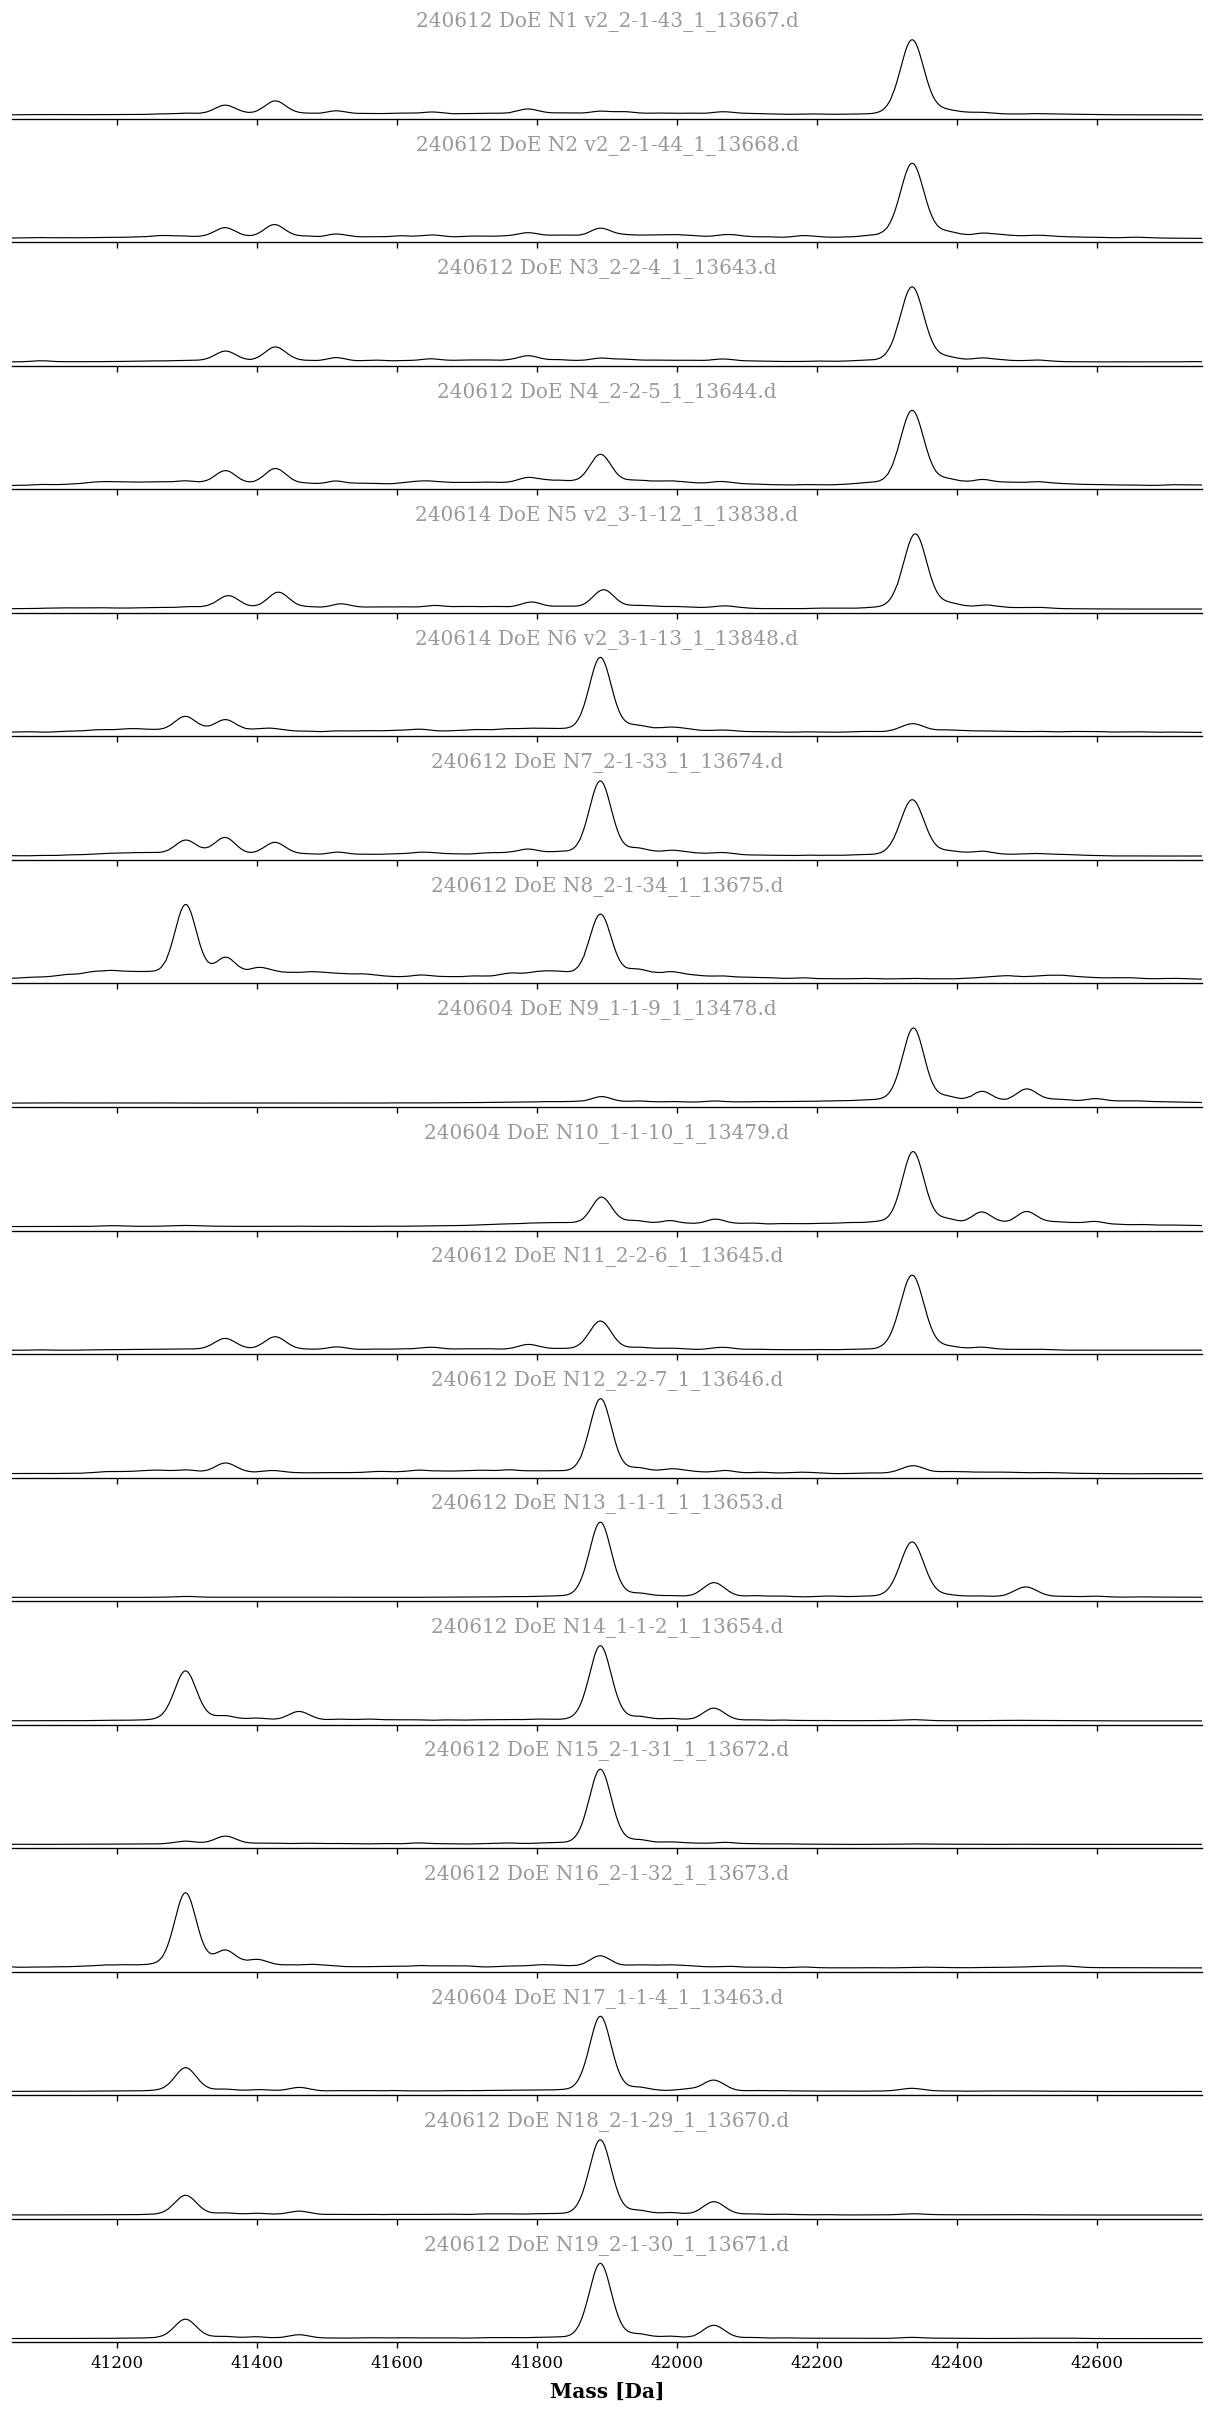

In [23]:
msp.plot_spectra_combined2(sorted_spectra,window = [41050, 42750], export = False, figsize=(10,20), show_titles=True)
plt.show()

In [13]:
df = eng.results1.copy()

df = df[df.Temp == 25]
df = df[df.Time==30]
df

AttributeError: 'DataFrame' object has no attribute 'Temp'

## Step 3: Quantification and analysis
A variety of useful statistical plotting tools taken from [Seaborn](https://seaborn.pydata.org/) and [Matplotlib](https://matplotlib.org/) can used to display your quantified data. Defined variables can be used to filter and select subsets of the data. 

In [ ]:
x="Catalyst"
y='Time'
z='Substrate'
c = 'Percentage_Labelling'
on=['CTB-LPETGVSEYG',"CTB-LPET" ]
df=eng.results1
df=eng.results1[df.Temp==4]
msp.plot3d(x, y, z, df, on, on_column='Label',c=c)

df=eng.results1[eng.results1.Temp==25]
msp.plot3d(x, y, z, df, on, on_column='Label',c=c)

In [ ]:
x="Time"
y='Percentage_Labelling'
z='GVSEYG'
on=['CTB-LPETGVSEYG', "CTB-LPET"]
on_column='Label'
# on=None
# on_column=None
msp.plot_data(df=eng.results1, x=x, y=y, on=on, hue=on_column, on_column=on_column,palette=eng.colors_dict)


In [ ]:
import matplotlib 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'serif'

p1=sns.relplot(eng.results1, x='Time', y='Percentage_Labelling', hue='Label',col='Catalyst', row='Substrate', palette=eng.colors_dict,legend="full")
ax = p1.axes[0,0]

ax.set_ylim(0, 100)

plt.show()